# Deteccion de Patrones VCP (Volatility Contraction Pattern)

## Contexto

El **VCP** (*Volatility Contraction Pattern*) es un patron de consolidacion definido por Mark Minervini
en su metodo SEPA (*Specific Entry Point Analysis*). La idea central es que, despues de un avance
significativo, una accion forma una base donde:

1. Las **contracciones de precio** (caidas desde maximo local a minimo local) son cada vez menores.
2. La **volatilidad** (medida por ATR) se comprime progresivamente.
3. El **volumen** decrece durante la formacion, indicando que la oferta se seca.
4. Cuando el precio supera el **pivote** (ultima resistencia) con volumen alto, se genera la **senal de compra**.

Este notebook implementa el pipeline completo de deteccion sobre datos reales de **NVIDIA (NVDA)**
durante ~10 anios, usando los modulos de `src/vcp_detection/heuristic/`.

### Pipeline de deteccion

```
OHLCV data
    |
    v
[1] Swing Detection (ATR ZigZag)     -> list[SwingPoint]
    |
    v
[2] Contraction Calculation           -> list[Contraction]
    |
    v
[3] Decreasing Sequence Detection     -> DecreasingSequence | None
    + Quality Filters (max_depth,
      min_total_reduction)
    |
    v
[4] ATR Compression Verification      -> ATRCompressionResult
    |
    v
[5] Volume Contraction Verification   -> VolumeContractionResult
    (volumen decreciente en la base)
    |
    v
[6] Pivot + Breakout Signal           -> VCPSignal | None
    (con confirmacion de volumen)
```

In [81]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Asegurar que src/ esta en el path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.configs import ATRZigZagConfig
from src.vcp_detection.heuristic import (
    ATRZigZagDetector,
    compute_contractions,
    contractions_to_dataframe,
    detect_breakout_signal,
    detect_decreasing_sequence,
    identify_pivot,
    run_full_vcp_pipeline,
    verify_atr_compression,
)

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 110,
})

## 1. Carga de datos

Usamos datos diarios de NVDA desde enero 2018 hasta abril 2026 (~8 anios, ~2077 barras de trading).
El CSV contiene columnas OHLCV + VWAP + transactions.

In [82]:
csv_path = project_root / "data" / "csv" / "NVDA.csv"
ohlc_full = pd.read_csv(csv_path, parse_dates=["date"], index_col="date")

START_DATE = "2016-01-01"
ohlc = ohlc_full.loc[START_DATE:].copy()

print(f"Ticker:      NVDA")
print(f"Periodo:     {ohlc.index[0].date()} a {ohlc.index[-1].date()}")
print(f"Barras:      {len(ohlc)}")
print(f"Columnas:    {list(ohlc.columns)}")
ohlc.head(3)

Ticker:      NVDA
Periodo:     2016-01-04 a 2026-04-08
Barras:      2580
Columnas:    ['open', 'high', 'low', 'close', 'volume', 'vwap', 'transactions']


,open,high,low,close,volume,vwap,transactions
date,,,,,,,
2016-01-04,0.8073,0.8145,0.8010,0.8093,358076280.0000,0.8071,56930
2016-01-05,0.8245,0.8360,0.8125,0.8223,490272560.0000,0.8260,64463
2016-01-06,0.8088,0.8125,0.7790,0.7883,449344160.0000,0.7960,70690


## 2. Configuracion de parametros

Cada etapa del pipeline tiene parametros configurables. A continuacion se justifica cada eleccion.

### 2.1 Swing Detection — ATR ZigZag

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| `atr_length` | 14 | Estandar de la industria para ATR (Average True Range). 14 barras diarias capturan ~3 semanas de volatilidad. |
| `atr_mult` | 2.0 | El precio debe revertir al menos **2x el ATR** desde un extremo para confirmar un swing. Valores menores (1.0-1.5) generan demasiados swings ruidosos; valores mayores (3.0+) pierden patrones reales. 2.0 es el balance entre sensibilidad y ruido. |
| `use_close_only` | True | Usa close para detectar extremos. |

**Por que ATR ZigZag y no Scipy Peaks?** ATR ZigZag es inherentemente **causal** — procesa barra a barra sin ver el futuro. Cada swing tiene un `confirmed_at` explicito que marca cuando se confirmo la reversion. En pruebas sobre NVDA mostro **50.2% de precision** en picos vs 27.4% de Scipy Peaks.

### 2.2 Secuencia decreciente — Tolerance + Quality Filters

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| `method` | `"tolerance"` | Permite que una contraccion sea hasta un 10% mayor que la anterior sin romper la monotonia. En datos reales, el ruido de mercado hace que el metodo `strict` rechace VCPs validos por diferencias triviales (ej: 6.7% seguido de 6.8%). |
| `min_contractions` | 2 | Minimo para que exista un patron — Minervini describe VCPs con 2 a 5 contracciones. |
| `max_contractions` | 6 | Limite superior. Bases con mas de 6 contracciones suelen ser consolidaciones laterales, no VCPs. |
| `lookback_bars` | 126 | ~6 meses de trading. Ventana temporal para buscar contracciones. Cubre bases intermedias (8-26 semanas). |
| `tolerance` | 0.10 | 10% de margen. Si la contraccion anterior fue 8.0%, se acepta hasta 8.8% en la siguiente. |
| `max_depth_pct` | **0.25** | Contracciones individuales mayores al 25% indican una caida de Stage 4, no una base saludable. Se rechazan secuencias que contengan alguna contraccion mayor a este umbral. |
| `min_total_reduction` | **0.70** | La ultima contraccion debe ser como maximo el 70% de la primera. Esto rechaza secuencias como 17.9% -> 17.6% que son "tecnicamente decrecientes" pero no muestran compresion real de volatilidad. |

### 2.3 Compresion de ATR — Ratio

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| `method` | `"ratio"` | Compara ATR al inicio vs al final del patron: `ATR_end / ATR_start <= threshold`. Simple y directo. |
| `atr_period` | 14 | Consistente con el periodo usado en swing detection. |
| `ratio_threshold` | **0.85** | Exige una compresion de al menos 15% del ATR. El default original (0.70) rechaza ~88% de VCPs validos en equities reales; 0.95 era demasiado laxo (solo 5% de compresion). 0.85 es el balance. |

### 2.4 Contraccion de volumen durante la base

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| `method` | `"ratio"` | Compara volumen promedio de la primera contraccion vs la ultima: `vol_last / vol_first <= threshold`. |
| `volume_column` | `"volume"` | Columna estandar de volumen. |
| `ratio_threshold` | **0.85** | El volumen promedio en la ultima contraccion debe ser como maximo 85% del volumen en la primera. Confirma que la oferta se seca durante la formacion de la base — condicion central de Minervini. |

### 2.5 Senal de Breakout — Volumen ratio

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| `volume_method` | `"ratio"` | El volumen del dia de breakout debe ser >= 1.5x el promedio de los 50 dias previos. |
| `volume_ratio_threshold` | **1.5** | Valor clasico de Minervini: el breakout debe venir acompanado de un aumento de al menos 50% sobre el volumen medio. Esto confirma participacion institucional. |
| `volume_lookback_days` | 50 | ~10 semanas. Baseline estable que no esta contaminado por eventos puntuales. |
| `require_volume_confirmation` | True | La confirmacion de volumen es central al metodo SEPA. Solo se bypasea en mercados sin volumen centralizado (FX). |

In [97]:
# --- Swing Detection ---
SWING_CONFIG = ATRZigZagConfig(
    atr_length=14,
    atr_mult=2.0,
    use_close_only=False,
)
swing_detector = ATRZigZagDetector(SWING_CONFIG)

# --- Decreasing Sequence ---
SEQUENCE_PARAMS = {
    "method": "tolerance",
    "min_contractions": 2,
    "max_contractions": 6,
    "lookback_bars": 126,
    "tolerance": 0.10,
    # Quality filters (mejora #3)
    "max_depth_pct": 0.35,          # rechazar contracciones individuales > 25%
    "min_total_reduction": 0.80,    # la ultima depth debe ser <= 70% de la primera
}

# --- ATR Compression ---
COMPRESSION_PARAMS = {
    "method": "ratio",
    "atr_period": 14,
    "ratio_threshold": 0.85,       # mejora #1: exige 15% de compresion minima
}

# --- Volume Contraction durante formacion (mejora #2) ---
VOLUME_CONTRACTION_PARAMS = {
    "method": "ratio",
    "volume_column": "volume",
    "ratio_threshold": 0.85,       # vol_last / vol_first <= 0.85
}

# --- Breakout Signal ---
BREAKOUT_PARAMS = {
    "volume_method": "ratio",
    "volume_ratio_threshold": 1.5,  # mejora #1: Minervini clasico (1.5x promedio)
    "volume_lookback_days": 50,
    "require_volume_confirmation": False,
}

print("Configuracion cargada.")

Configuracion cargada.


## 3. Ejecucion del pipeline

Ejecutamos el pipeline completo sobre todas las barras del periodo. Para cada fecha, el pipeline
evalua si existe un VCP valido con senal de compra.

> **Nota sobre senales repetidas**: el pipeline genera una senal cada dia que el close supera el
> pivote con volumen suficiente. Esto produce multiples senales consecutivas para el mismo patron
> subyacente. En la seccion 4 agrupamos estas senales en **patrones distintos** — un patron VCP
> cuenta como detectado si y solo si produce al menos una senal de compra.

In [98]:
results = run_full_vcp_pipeline(
    ohlc=ohlc,
    swing_detector=swing_detector,
    sequence_params=SEQUENCE_PARAMS,
    compression_params=COMPRESSION_PARAMS,
    breakout_params=BREAKOUT_PARAMS,
    volume_contraction_params=VOLUME_CONTRACTION_PARAMS,  # mejora #2
)

all_signals = {dt: sig for dt, sig in results.items() if sig is not None}
print(f"Barras evaluadas:     {len(results):,}")
print(f"Senales de compra:    {len(all_signals)}")

Barras evaluadas:     2,580
Senales de compra:    95


## 4. Agrupacion en patrones distintos

Multiples senales consecutivas que comparten el mismo pivote pertenecen al mismo patron VCP.
Agrupamos por `pivot_price` y tomamos la **primera senal** de cada grupo como la entrada
operativa del patron.

In [99]:
def group_signals_into_patterns(
    signals: dict[pd.Timestamp, "VCPSignal"],
    max_gap_days: int = 30,
) -> list[dict]:
    """Agrupa senales consecutivas en patrones VCP distintos.

    Dos senales pertenecen al mismo patron si estan separadas por menos de
    `max_gap_days` dias de calendario. Dentro de cada grupo, se toma la
    primera senal como entrada operativa.
    """
    if not signals:
        return []

    sorted_dates = sorted(signals.keys())
    patterns = []
    current_group = [sorted_dates[0]]

    for i in range(1, len(sorted_dates)):
        gap = (sorted_dates[i] - sorted_dates[i - 1]).days
        if gap <= max_gap_days:
            current_group.append(sorted_dates[i])
        else:
            patterns.append(current_group)
            current_group = [sorted_dates[i]]
    patterns.append(current_group)

    result = []
    for group in patterns:
        first_sig = signals[group[0]]
        vol_contr = first_sig.volume_contraction
        vol_ratio = (
            vol_contr.method_metrics.get("ratio_observed")
            if vol_contr is not None else None
        )
        result.append({
            "first_signal_date": group[0],
            "last_signal_date": group[-1],
            "n_signal_days": len(group),
            "pivot_price": first_sig.pivot_price,
            "entry_price": first_sig.entry_price,
            "suggested_stop": first_sig.suggested_stop,
            "stop_distance_pct": first_sig.suggested_stop_distance_pct,
            "n_contractions": first_sig.metadata["n_contractions"],
            "depths_pct": first_sig.metadata["depths_pct"],
            "atr_ratio": first_sig.atr_compression.method_metrics.get("ratio_observed"),
            "vol_contr_ratio": vol_ratio,
            "signal_obj": first_sig,
        })
    return result


patterns = group_signals_into_patterns(all_signals)
print(f"Patrones VCP distintos detectados: {len(patterns)}")
print(f"(de {len(all_signals)} senales totales en {len(ohlc):,} barras)\n")

summary_rows = []
for i, p in enumerate(patterns, 1):
    depths_str = " -> ".join(f"{d:.1%}" for d in p["depths_pct"])
    vol_contr_str = f"{p['vol_contr_ratio']:.3f}" if p["vol_contr_ratio"] is not None else "N/A"
    summary_rows.append({
        "#": i,
        "Primera senal": p["first_signal_date"].strftime("%Y-%m-%d"),
        "Pivot ($)": f"{p['pivot_price']:.2f}",
        "Entry ($)": f"{p['entry_price']:.2f}",
        "Stop ($)": f"{p['suggested_stop']:.2f}",
        "Riesgo": f"{p['stop_distance_pct']:.1%}",
        "Contr.": p["n_contractions"],
        "ATR ratio": f"{p['atr_ratio']:.3f}",
        "Vol contr.": vol_contr_str,
        "Profundidades": depths_str,
        "Dias senal": p["n_signal_days"],
    })

df_summary = pd.DataFrame(summary_rows).set_index("#")
df_summary

Patrones VCP distintos detectados: 7
(de 95 senales totales en 2,580 barras)



,Primera senal,Pivot ($),Entry ($),Stop ($),Riesgo,Contr.,ATR ratio,Vol contr.,Profundidades,Dias senal
#,,,,,,,,,,
1,2017-05-10,2.67,3.03,2.56,15.6%,2,0.784,0.561,13.2% -> 4.2%,7
2,2019-03-13,4.13,4.22,3.62,14.1%,3,0.464,0.653,28.7% -> 18.6% -> 12.4%,15
3,2020-01-09,6.05,6.08,5.75,5.3%,2,0.820,0.677,9.5% -> 4.8%,11
4,2023-05-01,28.11,28.91,26.23,9.3%,3,0.797,0.847,11.4% -> 8.8% -> 6.7%,3
5,2024-01-08,50.43,52.25,47.32,9.4%,4,0.602,0.734,17.9% -> 17.6% -> 11.0% -> 6.2%,31
6,2024-10-07,127.67,127.72,115.14,9.8%,4,0.642,0.830,27.2% -> 24.5% -> 23.1% -> 9.8%,15
7,2025-07-03,158.71,159.34,151.49,4.9%,5,0.656,0.728,27.0% -> 29.5% -> 17.4% -> 7.4% -> 4.5%,13


## 5. Interpretacion de resultados

**Lectura de la tabla anterior:**
- **Pivot**: precio de resistencia que el precio debe superar para generar la senal.
- **Entry**: precio de close el dia de la primera señal (precio de entrada sugerido).
- **Stop**: ultimo swing low del patron — nivel natural de stop-loss (si el precio cae por debajo, el patron fallo).
- **Riesgo**: distancia porcentual entre entry y stop. Cuanto menor, mejor relacion riesgo/beneficio.
- **ATR ratio**: `ATR_fin / ATR_inicio`. Valores < 1.0 confirman compresion de volatilidad. Cuanto menor, mas compresion.
- **Profundidades**: secuencia de contracciones (ej: 11.4% -> 8.8% -> 6.7% -> 6.3%) — deben ser decrecientes.
- **Dias con senal**: cuantos dias consecutivos se mantuvo la senal activa (close > pivot con volumen).

## 6. Visualizacion de patrones

Para cada patron detectado, graficamos:
- **Panel superior**: precio (close) con swing points, pivote, zona de contracciones, y senal de compra.
- **Panel inferior**: volumen diario con la media movil de 50 dias (baseline del filtro de breakout).

In [100]:
def plot_vcp_pattern(
    ohlc: pd.DataFrame,
    pattern: dict,
    pattern_number: int,
    margin_bars_before: int = 40,
    margin_bars_after: int = 30,
) -> None:
    """Grafica un patron VCP con precio, contracciones, pivot, senal y volumen."""
    sig = pattern["signal_obj"]
    seq = sig.pivot_info.sequence
    contractions = seq.contractions

    # Rango del grafico: desde antes de la primera contraccion hasta despues de la senal
    pattern_start = contractions[0].high_swing.date
    signal_date = pattern["first_signal_date"]

    start_loc = max(0, ohlc.index.get_loc(pattern_start) - margin_bars_before)
    end_loc = min(len(ohlc) - 1, ohlc.index.get_loc(signal_date) + margin_bars_after)
    window = ohlc.iloc[start_loc : end_loc + 1]

    # Swing points del patron
    swing_highs_dates = [c.high_swing.date for c in contractions]
    swing_highs_prices = [c.high_swing.price for c in contractions]
    swing_lows_dates = [c.low_swing.date for c in contractions]
    swing_lows_prices = [c.low_swing.price for c in contractions]

    # Volumen media movil 50d
    vol_ma50 = ohlc["volume"].rolling(50, min_periods=1).mean()

    fig, (ax_price, ax_vol) = plt.subplots(
        2, 1, figsize=(14, 8), height_ratios=[3, 1],
        sharex=True, gridspec_kw={"hspace": 0.08},
    )

    # --- Panel de precio ---
    ax_price.plot(
        window.index, window["close"],
        color="#2c3e50", linewidth=1.2, label="Close", zorder=2,
    )

    # Contracciones como zonas sombreadas + flechas de profundidad
    colors_contraction = plt.cm.Blues(np.linspace(0.25, 0.55, len(contractions)))
    for i, c in enumerate(contractions):
        ax_price.axvspan(
            c.high_swing.date, c.low_swing.date,
            alpha=0.12, color=colors_contraction[i], zorder=0,
        )
        mid_date = c.high_swing.date + (c.low_swing.date - c.high_swing.date) / 2
        ax_price.annotate(
            f"C{i+1}\n{c.depth_pct:.1%}",
            xy=(mid_date, (c.high_swing.price + c.low_swing.price) / 2),
            fontsize=8, ha="center", va="center", color="#2c3e50",
            fontweight="bold",
        )

    # Swing highs y lows
    ax_price.scatter(
        swing_highs_dates, swing_highs_prices,
        marker="v", s=80, color="#e74c3c", zorder=4, label="Swing High",
    )
    ax_price.scatter(
        swing_lows_dates, swing_lows_prices,
        marker="^", s=80, color="#27ae60", zorder=4, label="Swing Low",
    )

    # Linea de pivote
    pivot_price = pattern["pivot_price"]
    pivot_date = contractions[-1].high_swing.date
    ax_price.axhline(
        pivot_price, color="#e67e22", linestyle="--", linewidth=1.5, alpha=0.8,
        label=f"Pivot ${pivot_price:.2f}",
    )

    # Linea de stop
    stop_price = pattern["suggested_stop"]
    ax_price.axhline(
        stop_price, color="#e74c3c", linestyle=":", linewidth=1.2, alpha=0.6,
        label=f"Stop ${stop_price:.2f}",
    )

    # Senal de compra
    entry_price = pattern["entry_price"]
    ax_price.scatter(
        [signal_date], [entry_price],
        marker="*", s=300, color="#f39c12", edgecolors="#e67e22",
        linewidth=1.5, zorder=5, label=f"BUY ${entry_price:.2f}",
    )

    depths_str = " -> ".join(f"{d:.1%}" for d in pattern["depths_pct"])
    ax_price.set_title(
        f"Patron VCP #{pattern_number} — NVDA — "
        f"Senal: {signal_date.strftime('%Y-%m-%d')}  |  "
        f"Contracciones: [{depths_str}]  |  "
        f"ATR ratio: {pattern['atr_ratio']:.3f}",
        fontsize=11, fontweight="bold", pad=10,
    )
    ax_price.set_ylabel("Precio (USD)", fontsize=10)
    ax_price.legend(loc="upper left", fontsize=8, framealpha=0.9)

    # --- Panel de volumen ---
    vol_window = window["volume"]
    vol_ma_window = vol_ma50.loc[window.index]

    vol_colors = [
        "#27ae60" if window["close"].iloc[i] >= window["open"].iloc[i]
        else "#e74c3c"
        for i in range(len(window))
    ]
    ax_vol.bar(
        window.index, vol_window, width=0.8, color=vol_colors, alpha=0.6, zorder=2,
    )
    ax_vol.plot(
        window.index, vol_ma_window,
        color="#3498db", linewidth=1.5, label="Vol MA(50)", zorder=3,
    )

    # Marcar volumen del dia de senal
    if signal_date in window.index:
        signal_vol = ohlc.loc[signal_date, "volume"]
        signal_ma = vol_ma50.loc[signal_date]
        vol_ratio = signal_vol / signal_ma if signal_ma > 0 else 0
        ax_vol.bar(
            [signal_date], [signal_vol], width=0.8,
            color="#f39c12", alpha=0.9, zorder=4,
            label=f"Breakout vol ({vol_ratio:.1f}x avg)",
        )

    ax_vol.set_ylabel("Volumen", fontsize=10)
    ax_vol.legend(loc="upper left", fontsize=8, framealpha=0.9)
    ax_vol.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K"
    ))

    ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax_vol.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    fig.autofmt_xdate(rotation=30)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_661272/2144602997.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


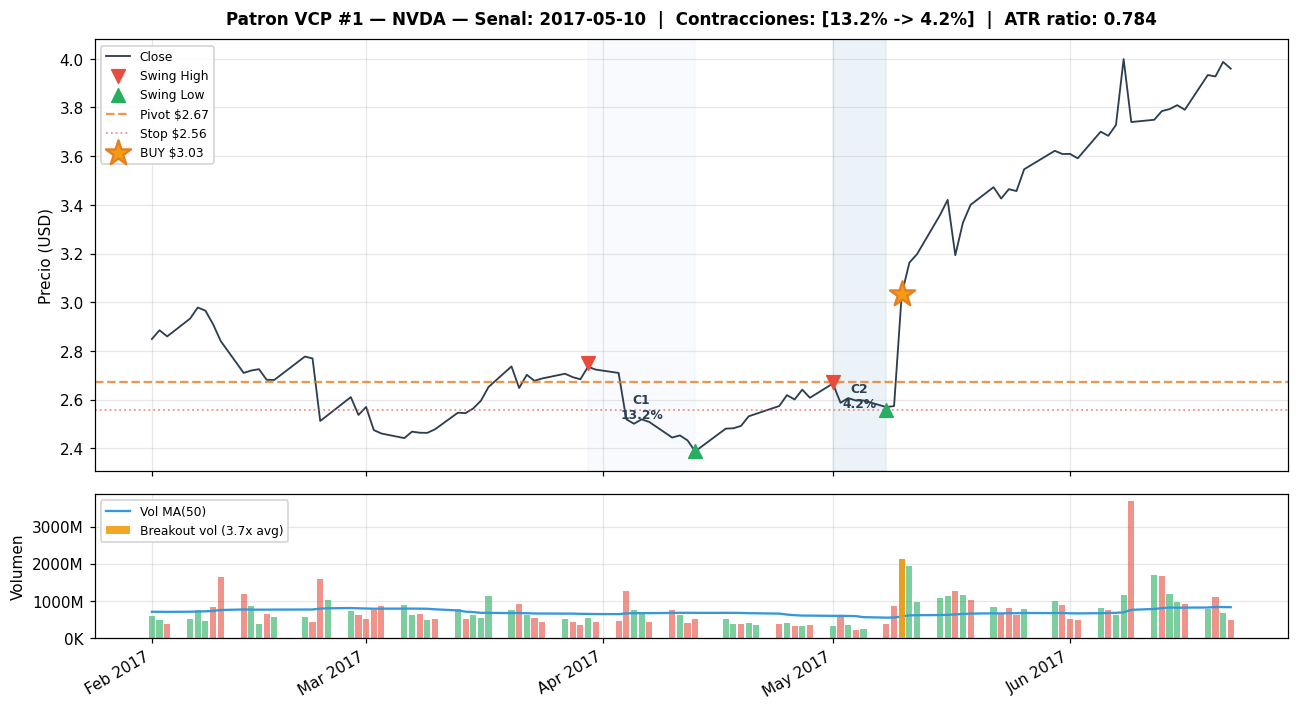

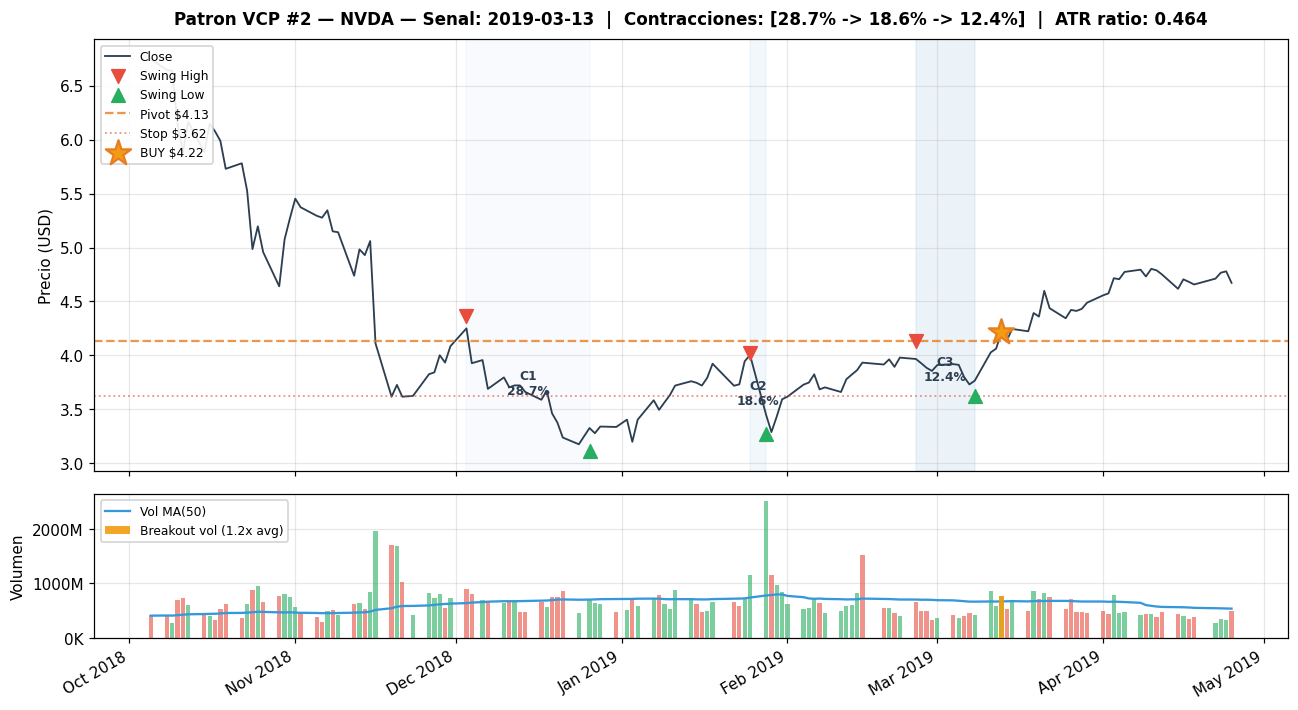

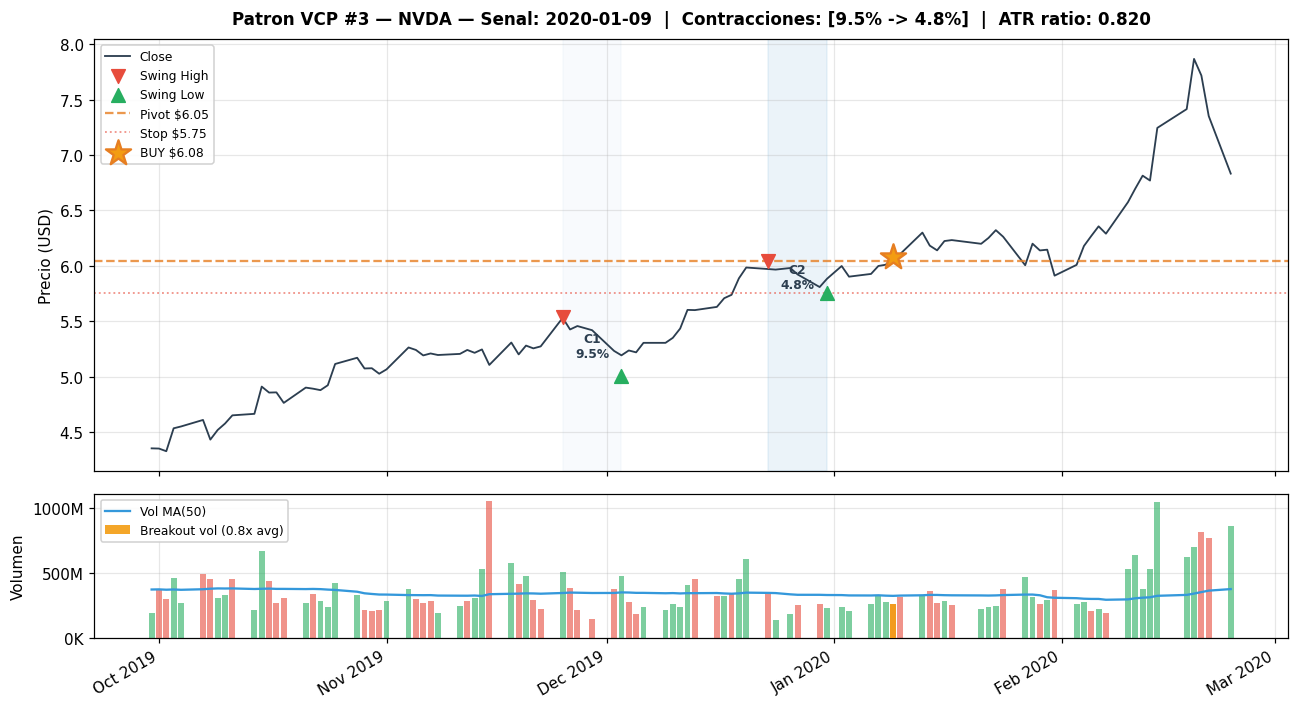

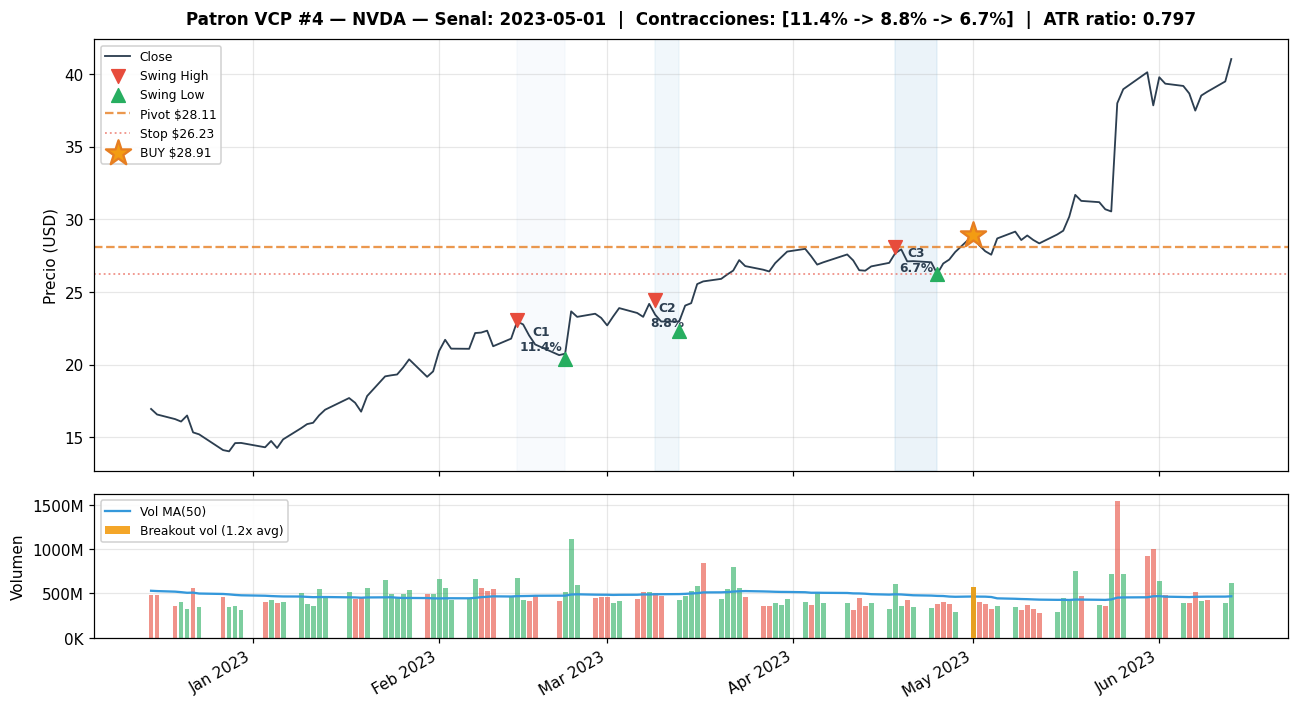

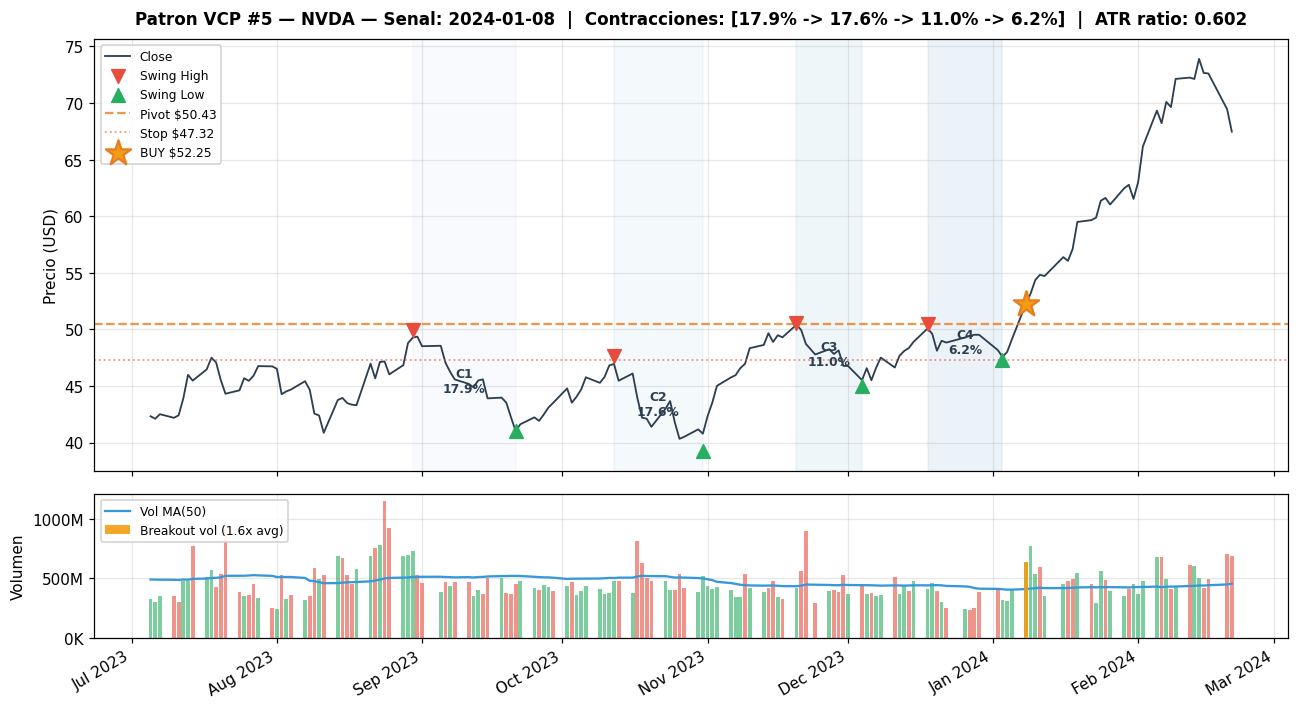

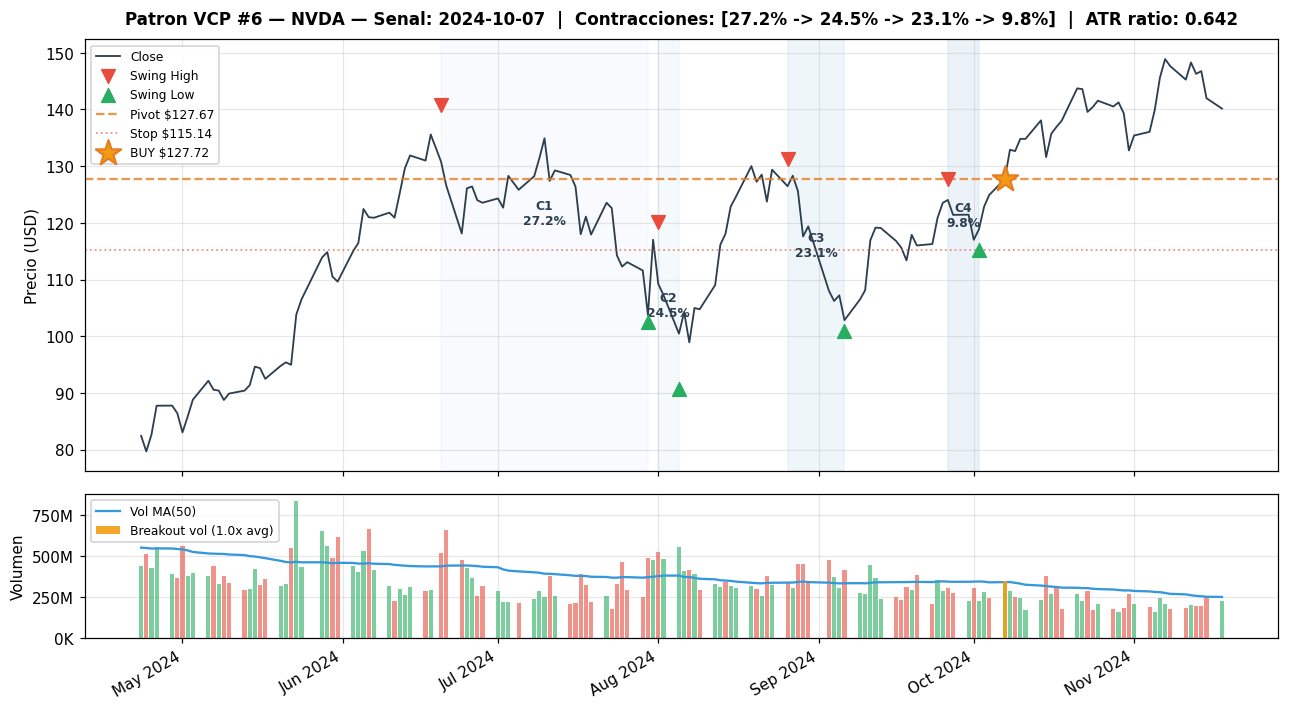

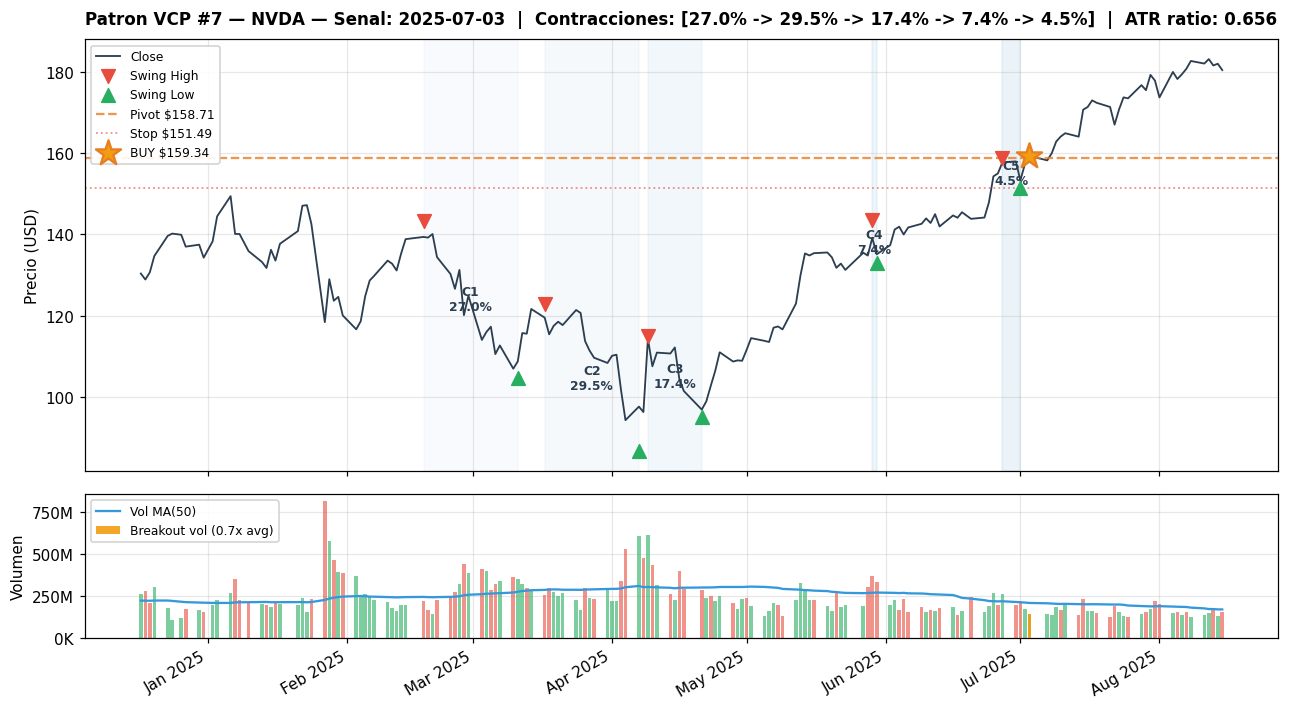

In [101]:
for i, pattern in enumerate(patterns, 1):
    plot_vcp_pattern(ohlc, pattern, pattern_number=i)

## 7. Detalle por patron

Analisis individual de cada patron: contracciones, compresion de ATR, y contexto de la senal.

In [ ]:
for i, p in enumerate(patterns, 1):
    sig = p["signal_obj"]
    seq = sig.pivot_info.sequence

    print(f"{'='*70}")
    print(f"PATRON VCP #{i}")
    print(f"{'='*70}")
    print(f"  Fecha de senal:      {p['first_signal_date'].strftime('%Y-%m-%d')}")
    print(f"  Precio de entrada:   ${p['entry_price']:.2f}")
    print(f"  Precio de pivote:    ${p['pivot_price']:.2f}")
    print(f"  Stop sugerido:       ${p['suggested_stop']:.2f} ({p['stop_distance_pct']:.1%} de riesgo)")
    print(f"  Contracciones:       {p['n_contractions']}")
    print(f"  ATR ratio:           {p['atr_ratio']:.3f} (threshold: 0.85)")
    print()

    print("  Contracciones individuales:")
    for j, c in enumerate(seq.contractions, 1):
        print(
            f"    C{j}: {c.high_swing.date.strftime('%Y-%m-%d')} (${c.high_swing.price:.2f}) "
            f"-> {c.low_swing.date.strftime('%Y-%m-%d')} (${c.low_swing.price:.2f})  "
            f"depth={c.depth_pct:.1%}  duration={c.duration_bars} bars"
        )
    print()

    # Quality filter metrics
    qm = seq.method_metrics
    if "max_depth_observed" in qm:
        print(f"  Filtros de calidad:")
        print(f"    Max depth:         {qm['max_depth_observed']:.1%} (threshold: {qm['max_depth_threshold']:.0%})")
        if "total_reduction_observed" in qm:
            print(f"    Total reduction:   {qm['total_reduction_observed']:.2f} (threshold: {qm['total_reduction_threshold']:.2f})")
        print()

    # Volume contraction during base
    vol_contr = sig.volume_contraction
    if vol_contr is not None:
        avg_vols_str = " -> ".join(f"{v:,.0f}" for v in vol_contr.avg_volumes)
        ratio_obs = vol_contr.method_metrics.get("ratio_observed", None)
        print(f"  Contraccion de volumen en la base:")
        print(f"    Metodo:            {vol_contr.method}")
        print(f"    Vol promedio/contr: {avg_vols_str}")
        if ratio_obs is not None:
            print(f"    Ratio last/first:  {ratio_obs:.3f} (threshold: {vol_contr.method_metrics.get('threshold', 'N/A')})")
        print(f"    Pasa:              {'Si' if vol_contr.passes else 'No'}")
        print()

    vol_info = sig.volume_confirmation
    if vol_info.get("applied", False):
        print(f"  Confirmacion de volumen en breakout:")
        print(f"    Metodo:            {vol_info['method']}")
        print(f"    Vol dia breakout:  {vol_info['volume_today']:,.0f}")
        print(f"    Vol promedio 50d:  {vol_info['volume_avg']:,.0f}")
        print(f"    Ratio:             {vol_info['value_observed']:.1f}x (minimo: {vol_info['threshold_value']:.1f}x)")
    print()

## 8. Panorama general: senales sobre la serie completa

Vista bird's-eye de NVDA con todos los patrones VCP marcados sobre el grafico de precio completo.

/tmp/ipykernel_627575/3964648376.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


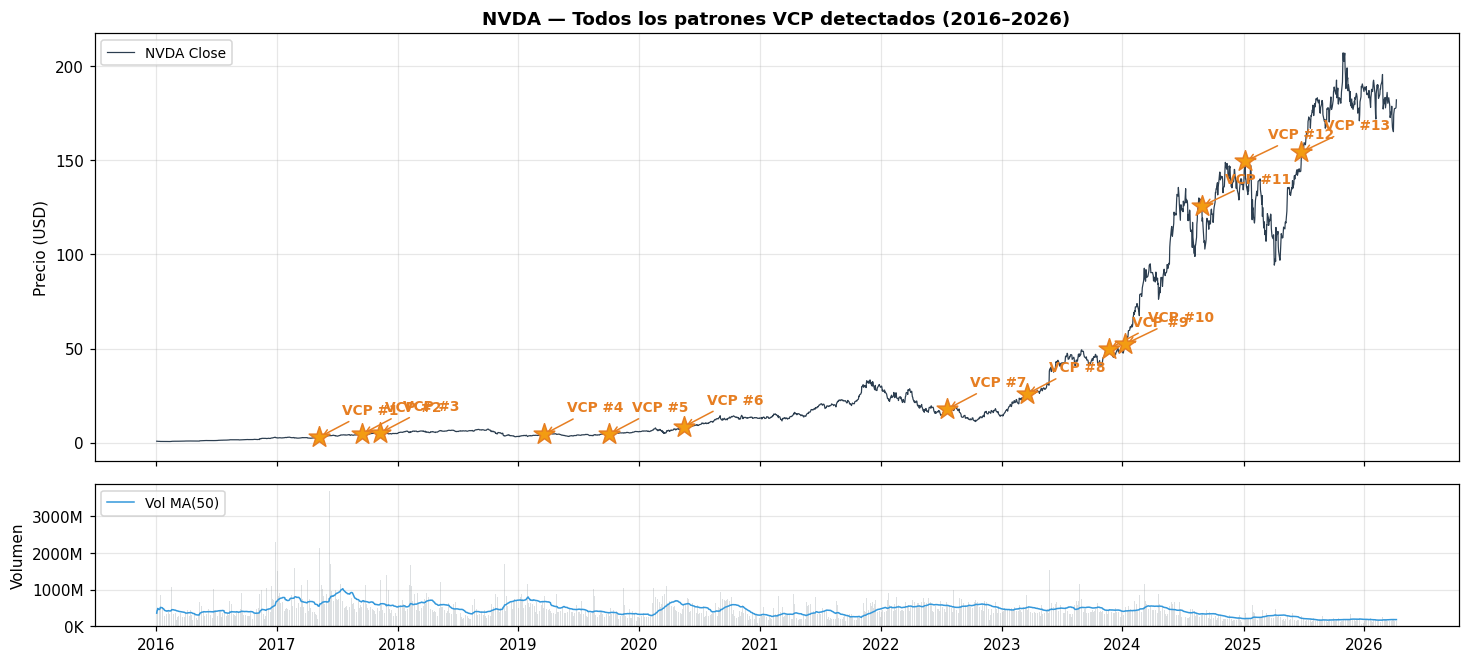

In [17]:
fig, (ax_price, ax_vol) = plt.subplots(
    2, 1, figsize=(16, 7), height_ratios=[3, 1],
    sharex=True, gridspec_kw={"hspace": 0.08},
)

ax_price.plot(ohlc.index, ohlc["close"], color="#2c3e50", linewidth=0.8, label="NVDA Close")

for i, p in enumerate(patterns, 1):
    sig_date = p["first_signal_date"]
    entry = p["entry_price"]
    ax_price.scatter(
        [sig_date], [entry],
        marker="*", s=200, color="#f39c12", edgecolors="#e67e22",
        linewidth=1, zorder=5,
    )
    ax_price.annotate(
        f"VCP #{i}",
        xy=(sig_date, entry),
        xytext=(15, 15), textcoords="offset points",
        fontsize=9, fontweight="bold", color="#e67e22",
        arrowprops={"arrowstyle": "->", "color": "#e67e22", "lw": 1},
    )

ax_price.set_title(
    f"NVDA — Todos los patrones VCP detectados ({ohlc.index[0].strftime('%Y')}–{ohlc.index[-1].strftime('%Y')})",
    fontsize=12, fontweight="bold",
)
ax_price.set_ylabel("Precio (USD)")
ax_price.legend(loc="upper left", fontsize=9)

vol_ma50 = ohlc["volume"].rolling(50, min_periods=1).mean()
ax_vol.bar(ohlc.index, ohlc["volume"], width=1.0, color="#bdc3c7", alpha=0.5)
ax_vol.plot(ohlc.index, vol_ma50, color="#3498db", linewidth=1.0, label="Vol MA(50)")
ax_vol.set_ylabel("Volumen")
ax_vol.legend(loc="upper left", fontsize=9)
ax_vol.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K"
))

ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_vol.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

## 9. Retorno post-senal

Para evaluar la calidad de las senales, calculamos el retorno del precio en los 5, 10, 20 y 60
dias posteriores a cada senal de compra.

> **Disclaimer**: Estos retornos son indicativos y estan sujetos a **survivorship bias** (NVDA
> sobrevivio y fue un outlier positivo). No deben interpretarse como evidencia de rentabilidad
> del metodo — para eso se necesita un backtest sobre un universo amplio con gestion de riesgo.

In [18]:
forward_windows = [5, 10, 20, 60]
return_rows = []

for i, p in enumerate(patterns, 1):
    sig_date = p["first_signal_date"]
    entry = p["entry_price"]
    sig_loc = ohlc.index.get_loc(sig_date)

    row = {"Patron": f"#{i}", "Fecha": sig_date.strftime("%Y-%m-%d"), "Entry ($)": f"{entry:.2f}"}
    for days in forward_windows:
        future_loc = sig_loc + days
        if future_loc < len(ohlc):
            future_price = ohlc["close"].iloc[future_loc]
            ret = (future_price - entry) / entry
            row[f"+{days}d"] = f"{ret:+.1%}"
        else:
            row[f"+{days}d"] = "N/A"
    return_rows.append(row)

df_returns = pd.DataFrame(return_rows).set_index("Patron")
df_returns

,Fecha,Entry ($),+5d,+10d,+20d,+60d
Patron,,,,,,
#1,2017-05-10,3.03,+5.3%,+14.2%,+31.9%,+37.9%
#2,2017-09-15,4.50,-0.6%,-0.7%,+8.0%,+8.1%
#3,2017-11-09,5.13,+3.1%,+5.7%,-6.7%,+11.4%
#4,2019-03-19,4.39,+0.7%,+4.1%,+7.1%,-15.6%
#5,2019-10-03,4.53,+0.9%,+7.2%,+10.9%,+28.1%
#6,2020-05-15,8.49,+6.3%,+3.7%,+8.0%,+27.8%
#7,2022-07-20,17.81,-0.1%,+6.1%,+3.0%,-32.8%
#8,2023-03-17,25.73,+4.1%,+8.0%,+5.0%,+59.5%
#9,2023-11-21,49.94,-3.6%,-8.9%,-3.7%,+39.1%


## 10. Resumen

### Resultados
- **Periodo analizado**: ~10 anios de NVDA (2016-2026), ~2,580 barras de trading.
- **Patrones VCP con senal de compra**: se reportan en la tabla de la seccion 4.
- **Definicion de patron**: un VCP cuenta si y solo si genera al menos una senal de compra
  (close > pivot + volumen >= 1.5x promedio 50d).

### Configuracion utilizada
| Componente | Metodo | Parametros clave |
|------------|--------|------------------|
| Swing detection | ATR ZigZag | `atr_mult=2.0`, `atr_length=14` |
| Monotonia | Tolerance | `tolerance=0.10`, `min_contractions=2`, `lookback=126` |
| Quality filters | max_depth + total_reduction | `max_depth_pct=0.25`, `min_total_reduction=0.70` |
| Compresion ATR | Ratio | `threshold=0.85` |
| Vol. contraccion base | Ratio | `threshold=0.85` |
| Breakout | Volumen ratio | `ratio=1.5x`, `lookback=50d` |

### Filtros aplicados (6 capas)
1. **Contracciones decrecientes** con tolerancia del 10%.
2. **Max depth**: ninguna contraccion individual > 25% (rechaza breakdowns de Stage 4).
3. **Min total reduction**: la ultima contraccion debe ser <= 70% de la primera (rechaza patrones sin compresion real).
4. **ATR compression**: la volatilidad al final del patron debe ser <= 85% de la inicial.
5. **Volume contraction**: el volumen en la ultima contraccion debe ser <= 85% del de la primera (oferta secandose).
6. **Breakout volume**: el volumen del dia de senal debe ser >= 1.5x el promedio de 50 dias (demanda institucional).

### Limitaciones
1. **Survivorship bias**: NVDA es una accion que sobrevivio y tuvo retornos excepcionales. Los retornos post-senal estan inflados.
2. **Sin filtro de Stage 2**: este detector no verifica que NVDA este en tendencia alcista (Stage 2 de Weinstein). Eso es responsabilidad del modulo de stage detection (`src/stage_detection/`), aun no integrado.
3. **Single ticker**: para validar el metodo se necesita un backtest sobre un universo amplio de acciones con gestion de riesgo.
4. **Senales no deduplicadas nativamente**: el pipeline genera una senal por dia — la deduplicacion por patron la hicimos manualmente en este notebook.